In [1]:
import xarray as xr
from pathlib import  Path
import pandas as pd

In [2]:
ARGO_NUMBER = 3902117

In [3]:
f = f"/home/ddyob/Documents/argo_piloting/sim/data/argo_data/argo_{ARGO_NUMBER}/{ARGO_NUMBER}_profiles.nc"
ds = xr.open_dataset(f)

/home/ddyob/Documents/argo_piloting/sim/.venv/bin/python: No module named pip


In [4]:

import numpy as np
import plotly.graph_objects as go

# Sort profiles by time
idx = np.argsort(ds['TIME'].values)
lat  = ds['LATITUDE'].values[idx]
lon  = ds['LONGITUDE'].values[idx]
time = ds['TIME'].values[idx]
pres = ds['PRES'].values[idx]          # (N_PROF, N_LEVELS)

time_num = (time - time[0]).astype('float64') / 1e9 / 86400  # days since first profile

# --- build vertical profile traces ---
traces = []
for i in range(len(idx)):
    valid = np.isfinite(pres[i])
    if not valid.any():
        continue
    depth = -pres[i, valid]            # pressure (dbar) ≈ depth (m), negative = below surface
    n     = valid.sum()
    traces.append(go.Scatter3d(
        x=np.full(n, lon[i]),
        y=np.full(n, lat[i]),
        z=depth,
        mode='lines',
        line=dict(
            color=np.full(n, time_num[i]),
            colorscale='Viridis',
            cmin=time_num.min(),
            cmax=time_num.max(),
            width=2,
        ),
        showlegend=False,
        hovertemplate=(
            f"Cycle {i+1}<br>"
            f"Lon: {lon[i]:.3f}°<br>"
            f"Lat: {lat[i]:.3f}°<br>"
            "Depth: %{z:.0f} m<extra></extra>"
        ),
    ))

# --- surface track ---
traces.append(go.Scatter3d(
    x=lon, y=lat, z=np.zeros(len(lon)),
    mode='lines+markers',
    name='Surface track',
    line=dict(color='white', width=2),
    marker=dict(
        size=3,
        color=time_num,
        colorscale='Viridis',
        cmin=time_num.min(),
        cmax=time_num.max(),
        colorbar=dict(title='Days since<br>first profile', x=1.02),
    ),
    hovertemplate="Lon: %{x:.3f}°<br>Lat: %{y:.3f}°<extra>Surface</extra>",
))

# --- waterline plane ---
lon_grid = np.linspace(lon.min(), lon.max(), 4)
lat_grid = np.linspace(lat.min(), lat.max(), 4)
LON, LAT = np.meshgrid(lon_grid, lat_grid)
traces.append(go.Surface(
    x=LON, y=LAT, z=np.zeros_like(LON),
    colorscale=[[0, 'rgba(0,120,200,0.25)'], [1, 'rgba(0,120,200,0.25)']],
    showscale=False,
    name='Waterline',
    hoverinfo='skip',
))

fig = go.Figure(data=traces)
fig.update_layout(
    title=f'Argo Float {ARGO_NUMBER} — 3D Profile Track',
    scene=dict(
        xaxis_title='Longitude (°)',
        yaxis_title='Latitude (°)',
        zaxis_title='Depth (m)',
        bgcolor='rgb(10, 30, 60)',
        xaxis=dict(gridcolor='grey'),
        yaxis=dict(gridcolor='grey'),
        zaxis=dict(gridcolor='grey', autorange='reversed'),
    ),
    paper_bgcolor='rgb(15, 20, 40)',
    font_color='white',
    margin=dict(l=0, r=0, t=40, b=0),
    height=700,
)
fig.show()


## Get command
Okay, so the goal of this is to get the commands sent to the float

In [5]:
# Sort profiles by time
from matplotlib import pyplot as plt
idx = np.argsort(ds['TIME'].values)
lat  = ds['LATITUDE'].values[idx]
lon  = ds['LONGITUDE'].values[idx]
time = ds['TIME'].values[idx]
pres = ds['PRES'].values[idx]
ds

<xarray.Dataset> Size: 682kB
Dimensions:          (N_PROF: 638, N_LEVELS: 80)
Coordinates:
  * N_PROF           (N_PROF) int64 5kB 316 317 315 318 314 ... 635 1 636 0 637
    LATITUDE         (N_PROF) float64 5kB 55.23 55.3 55.3 ... 55.45 55.45 55.45
    LONGITUDE        (N_PROF) float64 5kB 16.03 16.07 16.07 ... 16.94 16.94
    TIME             (N_PROF) datetime64[ns] 5kB 2023-02-22T22:51:00 ... 2024...
  * N_LEVELS         (N_LEVELS) int64 640B 0 1 2 3 4 5 6 ... 74 75 76 77 78 79
Data variables: (12/15)
    CYCLE_NUMBER     (N_PROF) int64 5kB ...
    DATA_MODE        (N_PROF) <U1 3kB ...
    DIRECTION        (N_PROF) <U1 3kB ...
    PLATFORM_NUMBER  (N_PROF) int64 5kB ...
    POSITION_QC      (N_PROF) int64 5kB ...
    PRES             (N_PROF, N_LEVELS) float32 204kB 5.2 5.9 6.9 ... nan nan
    ...               ...
    PSAL_ERROR       (N_PROF) float32 3kB ...
    PSAL_QC          (N_PROF) int64 5kB ...
    TEMP             (N_PROF, N_LEVELS) float32 204kB ...
    TEMP_ERROR       (N_PROF) float32 3kB ...
    TEMP_QC          (N_PROF) int64 5kB ...
    TIME_QC          (N_PROF) int64 5kB ...
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           ddyob
    Fetched_date:         2026/05/27
    Fetched_constraints:  WMO3902117
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [6]:
trajectory = xr.open_dataset(f"~/Documents/argo_piloting/sim/data/argo_data/argo_{ARGO_NUMBER}/{ARGO_NUMBER}_Rtraj.nc")

/tmp/ipykernel_507673/4060160396.py:1: FutureWarning: In a future version, xarray will not decode the variable 'CLOCK_OFFSET' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  trajectory = xr.open_dataset(f"~/Documents/argo_piloting/sim/data/argo_data/argo_{ARGO_NUMBER}/{ARGO_NUMBER}_Rtraj.nc")


In [7]:
trajectory

<xarray.Dataset> Size: 11MB
Dimensions:                              (N_PARAM: 8, N_MEASUREMENT: 29992,
                                          N_CYCLE: 331, N_CALIB_PARAM: 1,
                                          N_CALIB_JULD: 1, N_HISTORY: 51)
Dimensions without coordinates: N_PARAM, N_MEASUREMENT, N_CYCLE, N_CALIB_PARAM,
                                N_CALIB_JULD, N_HISTORY
Data variables: (12/129)
    DATA_TYPE                            object 8B ...
    FORMAT_VERSION                       object 8B ...
    HANDBOOK_VERSION                     object 8B ...
    REFERENCE_DATE_TIME                  object 8B ...
    DATE_CREATION                        object 8B ...
    DATE_UPDATE                          object 8B ...
    ...                                   ...
    HISTORY_PARAMETER                    (N_HISTORY) object 408B ...
    HISTORY_PREVIOUS_VALUE               (N_HISTORY) float32 204B ...
    HISTORY_INDEX_DIMENSION              (N_HISTORY) object 408B ...
    HISTORY_START_INDEX                  (N_HISTORY) float64 408B ...
    HISTORY_STOP_INDEX                   (N_HISTORY) float64 408B ...
    HISTORY_QCTEST                       (N_HISTORY) object 408B ...
Attributes:
    title:                        Argo float trajectory file
    institution:                  CORIOLIS
    source:                       Argo float
    history:                      2025-09-08T09:39:51Z creation; 2026-04-18T0...
    references:                   http://www.argodatamgt.org/Documentation
    user_manual_version:          3.4
    Conventions:                  Argo-3.2 CF-1.6
    featureType:                  trajectory
    decoder_version:              CODA_084c
    id:                           https://doi.org/10.17882/42182
    comment_on_resolution:        JULD and PRES variable resolutions depend o...
    comment_on_measurement_code:  Meaning of some specific measurement codes ...

In [8]:
# See all variables
for v in trajectory.data_vars:
    print(f"{v}: {trajectory[v].dims}, {trajectory[v].shape}")

DATA_TYPE: (), ()
FORMAT_VERSION: (), ()
HANDBOOK_VERSION: (), ()
REFERENCE_DATE_TIME: (), ()
DATE_CREATION: (), ()
DATE_UPDATE: (), ()
PLATFORM_NUMBER: (), ()
PROJECT_NAME: (), ()
PI_NAME: (), ()
TRAJECTORY_PARAMETERS: ('N_PARAM',), (8,)
DATA_CENTRE: (), ()
DATA_STATE_INDICATOR: (), ()
PLATFORM_TYPE: (), ()
FLOAT_SERIAL_NO: (), ()
FIRMWARE_VERSION: (), ()
WMO_INST_TYPE: (), ()
POSITIONING_SYSTEM: (), ()
JULD: ('N_MEASUREMENT',), (29992,)
JULD_STATUS: ('N_MEASUREMENT',), (29992,)
JULD_QC: ('N_MEASUREMENT',), (29992,)
JULD_ADJUSTED: ('N_MEASUREMENT',), (29992,)
JULD_ADJUSTED_STATUS: ('N_MEASUREMENT',), (29992,)
JULD_ADJUSTED_QC: ('N_MEASUREMENT',), (29992,)
JULD_DATA_MODE: ('N_MEASUREMENT',), (29992,)
LATITUDE: ('N_MEASUREMENT',), (29992,)
LONGITUDE: ('N_MEASUREMENT',), (29992,)
POSITION_ACCURACY: ('N_MEASUREMENT',), (29992,)
POSITION_QC: ('N_MEASUREMENT',), (29992,)
AXES_ERROR_ELLIPSE_MAJOR: ('N_MEASUREMENT',), (29992,)
AXES_ERROR_ELLIPSE_MINOR: ('N_MEASUREMENT',), (29992,)
AXES_ERROR_

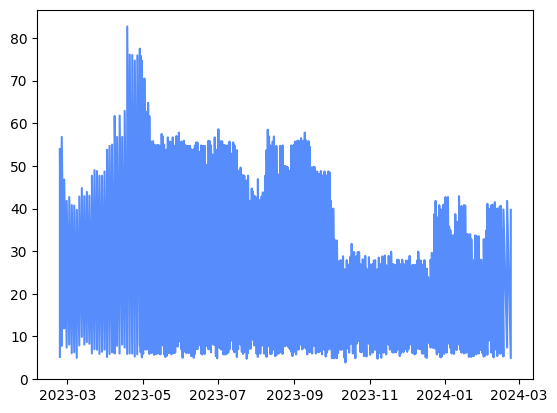

In [9]:
ds = trajectory
descent = ds.sel(N_MEASUREMENT = (ds.MEASUREMENT_CODE == 190))
descent_pres = descent.PRES.values
descent_juld = descent.JULD.values
plt.plot(descent_juld, descent_pres)

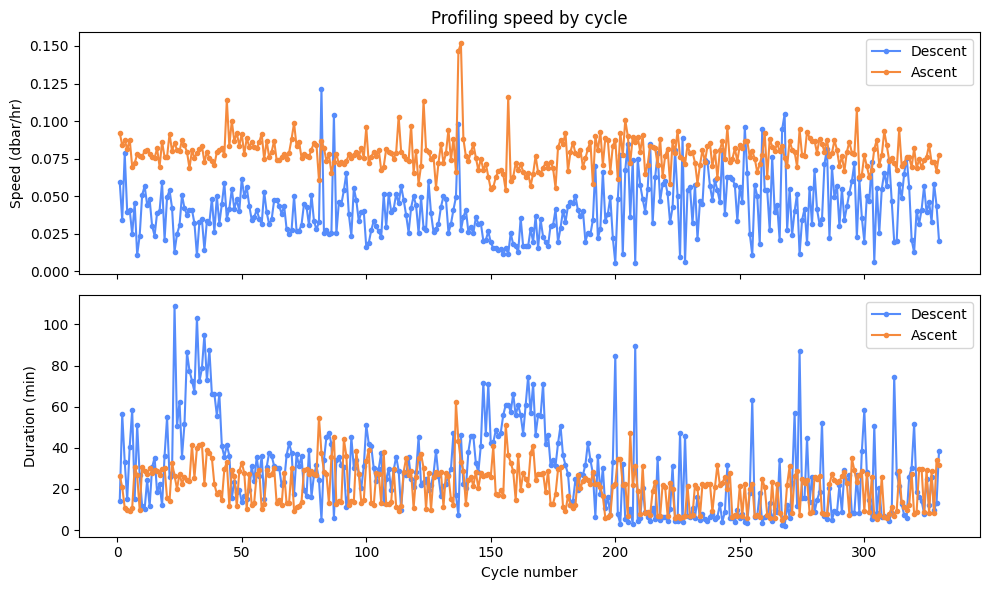

In [10]:
ds = trajectory

# First, check what measurement codes exist
# Descent codes are usually 500-599, ascent 700-799
# Adjust these after checking the output above
DESC_CODE = 190
ASC_CODE = 590

desc_speeds = []
asc_speeds = []
depth_reached = []

for cyc in np.unique(ds.CYCLE_NUMBER.values):
    if cyc > 0:
        if np.isnan(cyc):
            continue
        cmask = ds.CYCLE_NUMBER == cyc

        for label, codes, speeds_list in [("desc", DESC_CODE, desc_speeds),
                                           ("asc", ASC_CODE, asc_speeds)]:
            mask = ds.MEASUREMENT_CODE == codes
            total_mask = cmask & mask
            sub = ds.sel(N_MEASUREMENT=total_mask)

            if len(sub.N_MEASUREMENT) < 2:
                continue

            pres = sub.PRES.values
            juld = sub.JULD.values
            dps = np.diff(pres)
            dts = np.diff(juld) / np.timedelta64(1, "s")  # convert to seconds

            # Avoid division by zero
            valid = dts != 0
            speeds = np.abs(dps[valid]) / dts[valid]  # m/s (since dbar ≈ m)
            speed_average = np.median(speeds)
            total_dt = (juld[-1] - juld[0]) / np.timedelta64(1, "s")

            speeds_list.append((int(cyc), speed_average, total_dt / 60)) # cycle, speed, duration_min

# Convert to arrays
desc_arr = np.array(desc_speeds)  # columns: cycle, speed, duration_min
asc_arr = np.array(asc_speeds)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(desc_arr[:, 0], desc_arr[:, 1], ".-", label="Descent")
axes[0].plot(asc_arr[:, 0], asc_arr[:, 1], ".-", label="Ascent")
axes[0].set_ylabel("Speed (dbar/hr)")
axes[0].set_title("Profiling speed by cycle")
axes[0].legend()

axes[1].plot(desc_arr[:, 0], desc_arr[:, 2], ".-", label="Descent")
axes[1].plot(asc_arr[:, 0], asc_arr[:, 2], ".-", label="Ascent")
axes[1].set_ylabel("Duration (min)")
axes[1].set_xlabel("Cycle number")
axes[1].legend()

plt.tight_layout()
plt.show()

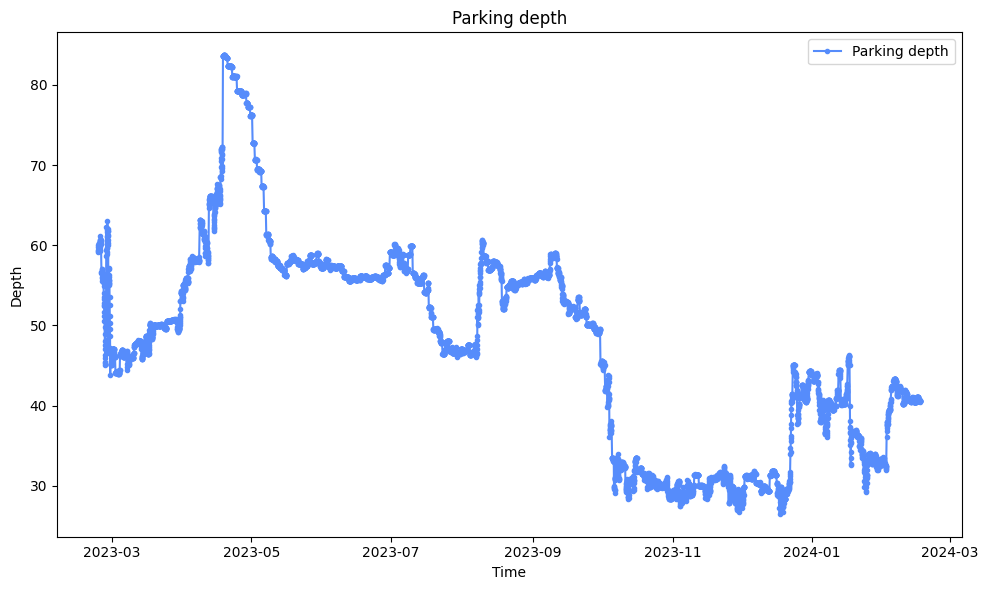

In [11]:
# plot parking depth
ds = trajectory

# First, check what measurement codes exist
# Descent codes are usually 500-599, ascent 700-799
# Adjust these after checking the output above
PARKING_CODE = 290

times = []
depths = []

for cyc in np.unique(ds.CYCLE_NUMBER.values):
    if np.isnan(cyc):
        continue
    cmask = ds.CYCLE_NUMBER == cyc
    parking_mask = ds.MEASUREMENT_CODE == PARKING_CODE
    sub = ds.sel(N_MEASUREMENT=parking_mask & cmask)

    juld = sub.JULD.values
    pres = sub.PRES.values

    times.append(juld)
    depths.append(pres)




times = np.concatenate(times)
depths = np.concatenate(depths)

# Convert to arrayslumns: cycle, speed, duration_min

fig, axes = plt.subplots(1, 1, figsize=(10, 6), sharex=True)

axes.plot(times, depths, ".-", label="Parking depth")
axes.set_ylabel("Depth")
axes.set_xlabel("Time")
axes.set_title("Parking depth")
axes.legend()

plt.tight_layout()
plt.show()

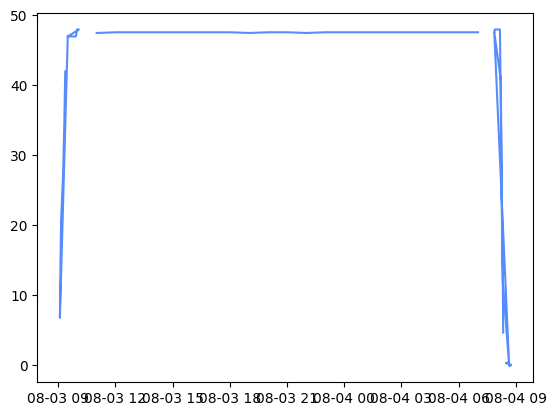

In [12]:

cmask = ds.CYCLE_NUMBER == 130

sub = ds.sel(N_MEASUREMENT=cmask)

pres = sub.PRES.values
juld = sub.JULD.values

plt.plot(juld,pres)



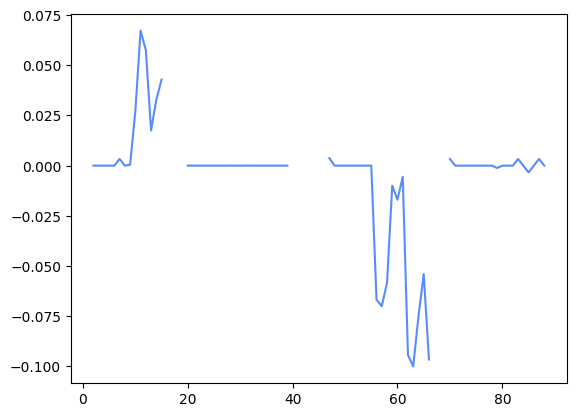

In [13]:

dps = np.diff(pres)
dts = np.diff(juld) / np.timedelta64(1, "s")  # convert to seconds

valid = dts != 0
speeds = dps[valid] / dts[valid]  # m/s (since dbar ≈ m)

plt.plot(speeds)

In [14]:
import sys
from datetime import datetime, timedelta
from pathlib import Path

_nb_dir  = Path("~/Documents/argo_piloting/sim/notebooks/Q_derivation").expanduser()
_src_dir = Path("~/Documents/argo_piloting/sim/src").expanduser()
# Insert src first, then nb_dir — nb_dir ends up at [0] and shadows src's
# sim_types / particle_mover while data_loader is still found in src.
for p in [str(_src_dir), str(_nb_dir)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from sim_types import ControlAction, GeoLocation, ProfilerState, TrajectoryRecord
from particle_mover import run_until_next_action
from data_loader import load_manifest, load_bathymetry, build_bathymetry_interpolator

# One-time setup: load manifest and bathymetry
data_dir = Path("~/Documents/argo_piloting/sim/data/raw").expanduser()
manifest = load_manifest(data_dir)
bathy_ds = load_bathymetry(data_dir / "D6_2024.nc")
bathy_interp = build_bathymetry_interpolator(bathy_ds)
print(f"Manifest: {len(manifest)} tiles, bathymetry loaded.")

Manifest: 400 tiles, bathymetry loaded.


In [15]:
import yaml
import math
import numpy as np

ds = trajectory
# Try _profiles.nc (argopy format) first, then _prof.nc (GDAC format)
_base = Path(f"~/Documents/argo_piloting/sim/data/argo_data/argo_{ARGO_NUMBER}").expanduser()
for _suf in ("_profiles.nc", "_prof.nc"):
    _p = _base / f"{ARGO_NUMBER}{_suf}"
    if _p.exists():
        DS_PROF = xr.open_dataset(_p).load()
        print(f"Loaded {_p.name}")
        break
else:
    raise FileNotFoundError(f"No profiles file found in {_base}")

DESC_CODE      = 190
PARKING_CODE   = 290
ASC_CODE       = 590
BATHY_TOLERANCE_M = 5.0

# -- Build profile-position lookup: cycle -> (lat, lon) --
_direction = DS_PROF["DIRECTION"].values
if _direction.dtype == object:  # GDAC bytes: b'A'
    asc_mask = np.array([d == b"A" for d in _direction])
else:                           # argopy unicode: 'A'
    asc_mask = _direction == "A"
prof_cyc = DS_PROF["CYCLE_NUMBER"].values[asc_mask].astype(int)
prof_lat = DS_PROF["LATITUDE"].values[asc_mask].astype(float)
prof_lon = DS_PROF["LONGITUDE"].values[asc_mask].astype(float)
_raw_qc  = DS_PROF["POSITION_QC"].values[asc_mask]
try:
    prof_qc = _raw_qc.astype(int)
except (ValueError, TypeError):
    prof_qc = np.array([int(q.decode().strip()) if isinstance(q, bytes)
                        else int(str(q).strip()) for q in _raw_qc])

profile_pos = {}
for c in np.unique(prof_cyc):
    idx  = np.where(prof_cyc == c)[0]
    good = idx[prof_qc[idx] == 1]
    use  = good if len(good) else idx
    profile_pos[int(c)] = (float(prof_lat[use[0]]), float(prof_lon[use[0]]))

print(f"Profile positions loaded for {len(profile_pos)} cycles "
      f"(range {min(profile_pos)} – {max(profile_pos)})")

# ── Helpers ──────────────────────────────────────────────────────────────────
def get_speed(sub_ds):
    pres = sub_ds.PRES.values
    juld = sub_ds.JULD.values
    dt   = np.diff(juld) / np.timedelta64(1, "s")
    valid = dt != 0
    if not valid.any():
        return None
    return float(np.nanmean(np.diff(pres)[valid] / dt[valid]))

def robust_start_pos(cycle_ds):
    """
    Fallback for cycles missing from profiles.nc.
    Uses code-703 GPS fixes sorted by JULD.
    If the first fix is confirmed within 30 s → genuine; use mean of early cluster.
    If not confirmed → bad pre-lock fix; skip it, use median of the rest.
    """
    mask_703 = cycle_ds.MEASUREMENT_CODE.values == 703
    lats = cycle_ds.LATITUDE.values.astype(float)[mask_703]
    lons = cycle_ds.LONGITUDE.values.astype(float)[mask_703]
    j    = cycle_ds.JULD.values.astype(float)[mask_703]
    valid = ~np.isnan(lats) & ~np.isnan(lons) & ~np.isnan(j)
    if not valid.any():
        all_lat = cycle_ds.LATITUDE.values.astype(float)
        all_lon = cycle_ds.LONGITUDE.values.astype(float)
        v = ~np.isnan(all_lat) & ~np.isnan(all_lon)
        return (float(np.median(all_lat[v])), float(np.median(all_lon[v]))) if v.any() else (None, None)
    lats, lons, j = lats[valid], lons[valid], j[valid]
    order = np.argsort(j)
    lats, lons, j = lats[order], lons[order], j[order]
    if len(lats) == 1:
        return float(lats[0]), float(lons[0])
    t_sec      = (j - j[0]) * 86400
    within_30  = t_sec[1:] <= 30
    close      = (np.abs(lons[1:] - lons[0]) <= 0.3) & (np.abs(lats[1:] - lats[0]) <= 0.3)
    confirmed  = (within_30 & close).any()
    if confirmed:
        early = (t_sec <= 60) & (np.abs(lons - lons[0]) <= 0.5) & (np.abs(lats - lats[0]) <= 0.5)
        return float(np.mean(lats[early])), float(np.mean(lons[early]))
    else:
        return float(np.median(lats[1:])), float(np.median(lons[1:]))

# ── Pass 1: collect per-cycle metadata ───────────────────────────────────────
cycle_numbers = sorted([int(c) for c in np.unique(ds.CYCLE_NUMBER.values)
                        if not np.isnan(c)])
cycle_meta = {}

for cyc in cycle_numbers:
    cmask    = ds.CYCLE_NUMBER == cyc
    cycle_ds = ds.sel(N_MEASUREMENT=cmask)

    juld = cycle_ds.JULD.values
    valid_juld = juld[~np.isnat(juld)]
    if len(valid_juld) == 0:
        continue

    # Start position: profiles.nc first, robust Rtraj fallback
    if cyc in profile_pos:
        start_lat, start_lon = profile_pos[cyc]
    else:
        start_lat, start_lon = robust_start_pos(cycle_ds)
        if start_lat is None:
            continue

    desc_sub = cycle_ds.sel(N_MEASUREMENT=cycle_ds.MEASUREMENT_CODE == DESC_CODE)
    asc_sub  = cycle_ds.sel(N_MEASUREMENT=cycle_ds.MEASUREMENT_CODE == ASC_CODE)

    desc_juld_arr = desc_sub.JULD.values
    desc_juld_arr = desc_juld_arr[~np.isnat(desc_juld_arr)]
    first_desc_juld = desc_juld_arr[0] if len(desc_juld_arr) > 0 else valid_juld[0]

    asc_juld_arr = asc_sub.JULD.values
    asc_juld_arr = asc_juld_arr[~np.isnat(asc_juld_arr)]
    last_asc_juld = asc_juld_arr[-1] if len(asc_juld_arr) > 0 else valid_juld[-1]

    cycle_meta[cyc] = {
        "start_lat": start_lat, "start_lon": start_lon,
        "start_time": str(valid_juld[0]), "end_time": str(valid_juld[-1]),
        "first_desc_juld": first_desc_juld,
        "last_asc_juld":   last_asc_juld,
        "cycle_ds": cycle_ds,
        "desc_sub": desc_sub, "asc_sub": asc_sub,
    }

# ── Pass 2: surface drift between consecutive cycles ─────────────────────────
surface_drift = {}

for i, cyc in enumerate(cycle_numbers[:-1]):
    next_cyc = cycle_numbers[i + 1]
    if cyc not in cycle_meta or next_cyc not in cycle_meta:
        continue

    last_asc   = cycle_meta[cyc]["last_asc_juld"]
    first_desc = cycle_meta[next_cyc]["first_desc_juld"]
    surface_duration_min = float((first_desc - last_asc) / np.timedelta64(1, "m"))

    # Stop position of this cycle = start position of next cycle (from profiles)
    end_lat = cycle_meta[cyc]["start_lat"]          # where THIS cycle surfaced
    end_lon = cycle_meta[cyc]["start_lon"]
    start_lat_next = cycle_meta[next_cyc]["start_lat"]  # where NEXT cycle starts
    start_lon_next = cycle_meta[next_cyc]["start_lon"]

    dlat_m = (start_lat_next - end_lat) * 111320.0
    dlon_m = (start_lon_next - end_lon) * 111320.0 * math.cos(math.radians(end_lat))
    displacement_m = math.sqrt(dlat_m**2 + dlon_m**2)
    duration_s     = max(surface_duration_min * 60, 1)
    speed_ms       = displacement_m / duration_s
    heading_deg    = math.degrees(math.atan2(dlon_m, dlat_m)) % 360

    surface_drift[cyc] = {
        "surface_duration_min":    round(surface_duration_min, 1),
        "surface_displacement_m":  round(displacement_m, 1),
        "mean_surface_speed_ms":   round(speed_ms, 6),
        "drift_heading_deg":       round(heading_deg, 1),
    }

# ── Pass 3: build YAML ────────────────────────────────────────────────────────
cycles_yaml = []

for cyc in cycle_numbers:
    if cyc not in cycle_meta:
        continue
    m        = cycle_meta[cyc]
    cycle_ds = m["cycle_ds"]
    start_lat, start_lon = m["start_lat"], m["start_lon"]

    # Stop position from profiles.nc (next cycle's ascending position)
    next_cyc = cycle_numbers[cycle_numbers.index(cyc) + 1] if cyc != cycle_numbers[-1] else None
    if next_cyc is not None and next_cyc in cycle_meta:
        stop_lat, stop_lon = cycle_meta[next_cyc]["start_lat"], cycle_meta[next_cyc]["start_lon"]
    else:
        stop_lat = stop_lon = None

    descent_speed = get_speed(m["desc_sub"]) if len(m["desc_sub"].N_MEASUREMENT) >= 2 else None
    ascent_speed  = get_speed(m["asc_sub"])  if len(m["asc_sub"].N_MEASUREMENT)  >= 2 else None

    park_sub = cycle_ds.sel(N_MEASUREMENT=cycle_ds.MEASUREMENT_CODE == PARKING_CODE)
    pres     = park_sub.PRES.values
    pres     = pres[~np.isnan(pres)]
    bathy_depth_m = float(bathy_interp(start_lat, start_lon))

    if len(pres) > 0:
        avg_bottom_depth = float(np.mean(pres))
        pres_range       = float(pres.max() - pres.min())
        parked_on_bottom = bool(abs(avg_bottom_depth - bathy_depth_m) <= BATHY_TOLERANCE_M)
    else:
        avg_bottom_depth = pres_range = None
        parked_on_bottom = None

    entry = {
        "cycle":                      cyc,
        "start_lat":                  round(start_lat, 5),
        "start_lon":                  round(start_lon, 5),
        "stop_lat":                   round(stop_lat, 5) if stop_lat is not None else None,
        "stop_lon":                   round(stop_lon, 5) if stop_lon is not None else None,
        "start_time":                 m["start_time"],
        "end_time":                   m["end_time"],
        "descent_speed_dbar_s":       round(descent_speed, 6) if descent_speed is not None else None,
        "ascent_speed_dbar_s":        round(ascent_speed,  6) if ascent_speed  is not None else None,
        "avg_bottom_depth_dbar":      round(avg_bottom_depth, 2) if avg_bottom_depth is not None else None,
        "parking_pressure_range_dbar":round(pres_range, 2)       if pres_range       is not None else None,
        "bathy_depth_m":              round(bathy_depth_m, 2),
        "parked_on_bottom":           parked_on_bottom,
    }
    entry.update(surface_drift.get(cyc, {
        k: None for k in ("surface_duration_min", "surface_displacement_m",
                          "mean_surface_speed_ms", "drift_heading_deg")
    }))
    cycles_yaml.append(entry)

# Fill missing speeds with fleet mean
mean_descent = float(np.nanmean([e["descent_speed_dbar_s"] for e in cycles_yaml if e["descent_speed_dbar_s"] is not None]))
mean_ascent  = float(np.nanmean([e["ascent_speed_dbar_s"]  for e in cycles_yaml if e["ascent_speed_dbar_s"]  is not None]))
for e in cycles_yaml:
    if e["descent_speed_dbar_s"] is None:
        e["descent_speed_dbar_s"] = round(mean_descent, 6)
    if e["ascent_speed_dbar_s"] is None:
        e["ascent_speed_dbar_s"] = round(mean_ascent, 6)

output_path = f"/home/ddyob/Documents/argo_piloting/sim/data/argo_data/argo_{ARGO_NUMBER}/cycle_summary.yaml"
with open(output_path, "w") as f:
    yaml.dump({"cycles": cycles_yaml}, f, default_flow_style=False, sort_keys=False)

print(f"Written {len(cycles_yaml)} cycles → {output_path}")
print(f"  Fleet mean descent: {mean_descent:.4f} dbar/s, ascent: {mean_ascent:.4f} dbar/s")
print(f"  Cycles from profiles.nc: {sum(1 for c in cycle_numbers if c in profile_pos and c in cycle_meta)}")
print(f"  Cycles from Rtraj fallback: {sum(1 for c in cycle_numbers if c not in profile_pos and c in cycle_meta)}")

Loaded 3902117_profiles.nc
Profile positions loaded for 321 cycles (range 1 – 330)
Written 332 cycles → /home/ddyob/Documents/argo_piloting/sim/data/argo_data/argo_3902117/cycle_summary.yaml
  Fleet mean descent: 0.0404 dbar/s, ascent: -0.0705 dbar/s
  Cycles from profiles.nc: 321
  Cycles from Rtraj fallback: 11


## Run a simulation using the actions created


In [16]:
import yaml
from pathlib import Path

yaml_path = Path(f"~/Documents/argo_piloting/sim/data/argo_data/argo_{ARGO_NUMBER}/cycle_summary.yaml").expanduser()

with open(yaml_path) as f:
    cycle_data = yaml.safe_load(f)

cycles = cycle_data["cycles"]

print(f"Loaded {len(cycles)} cycles")
cycles[1:180]

Loaded 332 cycles


[{'cycle': 0,
  'start_lat': 55.23161,
  'start_lon': 16.00592,
  'stop_lat': 55.29518,
  'stop_lon': 16.07109,
  'start_time': '2023-02-22T21:39:38.000000000',
  'end_time': '2023-02-22T21:48:29.999997440',
  'descent_speed_dbar_s': 0.040426,
  'ascent_speed_dbar_s': -0.070517,
  'avg_bottom_depth_dbar': None,
  'parking_pressure_range_dbar': None,
  'bathy_depth_m': 90.51,
  'parked_on_bottom': None,
  'surface_duration_min': 63.4,
  'surface_displacement_m': 8197.3,
  'mean_surface_speed_ms': 2.153796,
  'drift_heading_deg': 30.3},
 {'cycle': 1,
  'start_lat': 55.29518,
  'start_lon': 16.07109,
  'stop_lat': 55.23679,
  'stop_lon': 16.46471,
  'start_time': '2023-02-22T21:48:00.000000000',
  'end_time': '2023-02-22T23:46:00.000000000',
  'descent_speed_dbar_s': 0.058682,
  'ascent_speed_dbar_s': -0.076352,
  'avg_bottom_depth_dbar': 60.06,
  'parking_pressure_range_dbar': 1.9,
  'bathy_depth_m': 81.41,
  'parked_on_bottom': False,
  'surface_duration_min': 80.5,
  'surface_displacem

In [17]:
import sys
from datetime import datetime, timedelta
from pathlib import Path

_nb_dir  = Path("~/Documents/argo_piloting/sim/notebooks/Q_derivation").expanduser()
_src_dir = Path("~/Documents/argo_piloting/sim/src").expanduser()
for p in [str(_src_dir), str(_nb_dir)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from sim_types import ControlAction, GeoLocation, ProfilerState
from particle_mover import run_until_next_action
from data_loader import load_manifest, load_bathymetry, build_bathymetry_interpolator

data_dir = Path("~/Documents/argo_piloting/sim/data/raw").expanduser()
manifest = load_manifest(data_dir)
bathy_ds = load_bathymetry(data_dir / "D6_2024.nc")
bathy_interp = build_bathymetry_interpolator(bathy_ds)
print(f"Manifest: {len(manifest)} tiles, bathymetry loaded.")

Manifest: 400 tiles, bathymetry loaded.


## Replay loop — simulate real float cycles

Two modes run side-by-side:
- **Reset**: each cycle starts from the real observed position (tests single-cycle accuracy)  
- **Chained**: each cycle starts from wherever the sim ended (tests drift accumulation)

In [18]:
import numpy as np
def action_from_cycle(cyc, next_cyc=None):
    """Build a ControlAction from a YAML cycle entry.

    Cycle duration is derived from the time gap between this cycle's
    start_time and the next cycle's start_time. If there's no next
    cycle, falls back to the gap between this cycle's own start and
    end times.
    """
    t_start = np.datetime64(cyc["start_time"])

    if next_cyc is not None:
        t_next = np.datetime64(next_cyc["start_time"])

    else:
        t_next = np.datetime64(cyc["end_time"])

    surface_duration_min = cyc["surface_duration_min"] if cyc["surface_duration_min"] is not None else 30

    try:
        cycle_hours = (
            (t_next - t_start)
            - np.timedelta64(int(surface_duration_min), "m")
            - np.timedelta64(int(cyc["avg_bottom_depth_dbar"] / cyc["ascent_speed_dbar_s"]), "s")
        ) / np.timedelta64(1, "h")
    except:
        print("no correct time")
        cycle_hours = (t_next - t_start) / np.timedelta64(1, "h")

    # Decide park mode from the YAML flags
    if cyc["parked_on_bottom"]:
        park_mode = "park_on_bottom"
    elif cyc["avg_bottom_depth_dbar"] is not None:
        park_mode = "parking_depth"
    else:
        park_mode = "drift_on_surface"

    return ControlAction(
        park_mode=park_mode,
        cycle_hours=float(cycle_hours),
        transmission_duration_minutes=surface_duration_min,
        target_depth=cyc["avg_bottom_depth_dbar"],
        descent_speed_ms=abs(cyc["descent_speed_dbar_s"]) if cyc["descent_speed_dbar_s"] else 0.08,
        ascent_speed_ms=abs(cyc["ascent_speed_dbar_s"]) if cyc["ascent_speed_dbar_s"] else 0.08,
    )

# Quick sanity check
test_action = action_from_cycle(cycles[5], cycles[6])
print(f"cycle_hours={test_action.cycle_hours:.1f}  park_mode={test_action.park_mode}  "
      f"target_depth={test_action.target_depth}  descent={test_action.descent_speed_ms:.4f} m/s")

cycle_hours=48.7  park_mode=park_on_bottom  target_depth=46.23  descent=0.0387 m/s


In [19]:
FORCE_RERUN = False  # set True to re-run simulations; False loads from cache
_argo_dir = Path(f"~/Documents/argo_piloting/sim/data/argo_data/argo_{ARGO_NUMBER}").expanduser()
_cache_reset   = _argo_dir / f"{ARGO_NUMBER}_sim_reset.parquet"

if not FORCE_RERUN and _cache_reset.exists():
    df_reset   = pd.read_parquet(_cache_reset)
    print(f"Loaded from cache: {len(df_reset)} reset cycles")
    print(f"  ({_cache_reset.name})")
else:
    import pandas as pd
    import logging
    #logging.basicConfig(level=logging.DEBUG, format="%(asctime)s [%(levelname)s] %(name)s: %(message)s", force = True)

    START_CYCLE = 10   # <-- pick your starting cycle index here
    STOP_CYCLE  = None  # <-- set to a cycle index to stop early, or None to run to the end

    # Storage for both modes
    results_reset   = []

    all_records_reset   = []
    skipped_cycles = []

    stop = STOP_CYCLE if STOP_CYCLE is not None else len(cycles) - 1
    for i in range(START_CYCLE, stop):
        cyc      = cycles[i]
        next_cyc = cycles[i + 1]

        # Skip cycles with missing speed data
        if cyc['descent_speed_dbar_s'] is None or cyc['ascent_speed_dbar_s'] is None:
            print(f"Cycle {cyc['cycle']}: skipping - missing speed data")
            skipped_cycles.append({'cycle': cyc['cycle'], 'reason': 'missing speed data'})
            continue

        action = action_from_cycle(cyc, next_cyc)

        # Skip park_on_bottom cycles where bathymetry is unknown - float descends forever
        bathy = float(bathy_interp(cyc['start_lat'], cyc['start_lon']))
        if action.park_mode == 'park_on_bottom' and math.isnan(bathy):
            print(f"Cycle {cyc['cycle']}: skipping - park_on_bottom but bathy=nan at "
                  f"({cyc['start_lat']:.4f}, {cyc['start_lon']:.4f})")
            skipped_cycles.append({'cycle': cyc['cycle'], 'reason': 'park_on_bottom with bathy=nan'})
            continue

        t_start = pd.Timestamp(cyc['start_time']).to_pydatetime()

        print(f"\n{'='*60}")
        print(f"Cycle {cyc['cycle']} | {t_start} | action: {action.park_mode} "
              f"for {action.cycle_hours:.1f}h to {action.target_depth}m")
        print(f"{'='*60}")

        # --- Mode A: Reset to real position each cycle ---
        real_state = ProfilerState(
            time=t_start,
            location=GeoLocation(lat=cyc['start_lat'], lon=cyc['start_lon']),
            depth=0.0,
            phase='communicating',
            x=0.0,
            y=0.0,
        )

        try:
            recs_a, end_state_a = run_until_next_action(
                real_state, data_dir, manifest, bathy_interp, action, dt_vertical_seconds=30,
            )
            all_records_reset.extend(recs_a)
            results_reset.append({
                'cycle':          cyc['cycle'],
                'real_start_lat': cyc['start_lat'],
                'real_start_lon': cyc['start_lon'],
                'sim_end_lat':    end_state_a.location.lat,
                'sim_end_lon':    end_state_a.location.lon,
                'real_end_lat':   next_cyc['start_lat'],
                'real_end_lon':   next_cyc['start_lon'],
            })
            print(f"  [RESET]   sim ended at ({end_state_a.location.lat:.4f}, {end_state_a.location.lon:.4f}), "
                  f"real next at ({next_cyc['start_lat']:.4f}, {next_cyc['start_lon']:.4f})")
        except RuntimeError as e:
            if 'bathy_depth is NaN' in str(e):
                print(f"Cycle {cyc['cycle']}: skipping - {e}")
                skipped_cycles.append({'cycle': cyc['cycle'], 'reason': f'park_on_bottom with bathy=nan during descent'})
                continue
            print(f"  [RESET]   FAILED: {e}")
        except Exception as e:
            print(f"  [RESET]   FAILED: {e}")



    df_reset   = pd.DataFrame(results_reset)
    print(f"\nDone. Reset: {len(df_reset)} cycles")
    if skipped_cycles:
        print(f"Skipped {len(skipped_cycles)} cycles:")
        for s in skipped_cycles:
            print(f"  Cycle {s['cycle']}: {s['reason']}")
    df_reset.to_parquet(_cache_reset, index=False)
    print(f"Saved to {_cache_reset.name}")



Cycle 9 | 2023-03-10 15:40:00 | action: park_on_bottom for 48.3h to 47.76m
  [RESET]   FAILED: No tiles found for lat=55.423 lon=17.075 time=[2023-03-10 15:40:00, 2023-03-13 03:59:44] margin=0.5°. Float may have left the dataset domain.

Cycle 10 | 2023-03-12 16:38:00 | action: park_on_bottom for 48.2h to 47.22m
  [RESET]   FAILED: No tiles found for lat=55.424 lon=17.048 time=[2023-03-12 16:38:00, 2023-03-15 04:49:07] margin=0.5°. Float may have left the dataset domain.

Cycle 11 | 2023-03-14 17:52:00 | action: park_on_bottom for 48.4h to 47.63m
  [RESET]   FAILED: No tiles found for lat=55.433 lon=17.023 time=[2023-03-14 17:52:00, 2023-03-17 06:17:35] margin=0.5°. Float may have left the dataset domain.

Cycle 12 | 2023-03-16 18:36:00 | action: park_on_bottom for 48.4h to 48.58m
  [RESET]   FAILED: No tiles found for lat=55.421 lon=16.965 time=[2023-03-16 18:36:00, 2023-03-19 06:58:18] margin=0.5°. Float may have left the dataset domain.

Cycle 13 | 2023-03-18 19:35:00 | action: par

NaN velocity at lat=55.6675 lon=16.7755 depth=41.6 bathy=46.9 time=2023-09-30 10:41:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.6675 lon=16.7755 depth=42.5 bathy=46.9 time=2023-09-30 10:42:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.6675 lon=16.7755 depth=43.3 bathy=46.9 time=2023-09-30 10:42:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.6675 lon=16.7755 depth=44.1 bathy=46.9 time=2023-09-30 10:43:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.6675 lon=16.7755 depth=44.9 bathy=46.9 time=2023-09-30 10:43:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.6675 lon=16.7755 depth=45.7 bathy=46.9 time=2023-09-30 10:44:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.6675 lon=16.7755 depth=46.5 bathy=46.9 time=2023-09-30 10:44:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.6675 lon=16.7755 depth=46.9 bathy=46.9 time=2023-10-01 07:01:40 — defaulti

  [RESET]   sim ended at (55.6673, 16.7746), real next at (55.6733, 16.7920)

Cycle 189 | 2023-10-01 08:33:00 | action: park_on_bottom for 22.1h to 44.94m


NaN velocity at lat=55.6700 lon=16.7854 depth=41.7 bathy=45.4 time=2023-10-01 11:01:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.6700 lon=16.7854 depth=42.6 bathy=45.4 time=2023-10-01 11:02:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.6700 lon=16.7854 depth=43.4 bathy=45.4 time=2023-10-01 11:02:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.6700 lon=16.7854 depth=44.3 bathy=45.4 time=2023-10-01 11:03:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.6700 lon=16.7854 depth=45.1 bathy=45.4 time=2023-10-01 11:03:30 — defaulting to 0 during phase descending
NaN velocity at lat=55.6700 lon=16.7854 depth=45.4 bathy=45.4 time=2023-10-02 06:41:36 — defaulting to 0 during phase ascending
NaN velocity at lat=55.6700 lon=16.7854 depth=43.2 bathy=45.4 time=2023-10-02 06:42:06 — defaulting to 0 during phase ascending


  [RESET]   sim ended at (55.6702, 16.7856), real next at (55.6788, 16.8094)

Cycle 190 | 2023-10-02 08:34:00 | action: park_on_bottom for 21.4h to 42.22m


...

  [RESET]   sim ended at (55.4682, 16.9401), real next at (55.4618, 16.9398)

Cycle 326 | 2024-02-15 08:49:00 | action: park_on_bottom for 23.4h to 41.01m


NaN velocity at lat=55.4600 lon=16.9382 depth=42.5 bathy=43.2 time=2024-02-15 09:44:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.4600 lon=16.9382 depth=43.2 bathy=43.2 time=2024-02-16 08:12:01 — defaulting to 0 during phase ascending


  [RESET]   sim ended at (55.4601, 16.9381), real next at (55.4641, 16.9379)

Cycle 327 | 2024-02-16 08:41:00 | action: park_on_bottom for 23.2h to 40.6m


NaN velocity at lat=55.4664 lon=16.9385 depth=41.2 bathy=42.1 time=2024-02-16 09:58:00 — defaulting to 0 during phase descending
NaN velocity at lat=55.4664 lon=16.9385 depth=42.1 bathy=42.1 time=2024-02-17 07:53:06 — defaulting to 0 during phase ascending


  [RESET]   sim ended at (55.4661, 16.9382), real next at (55.4544, 16.9395)
no correct time

Cycle 328 | 2024-02-17 08:37:00 | action: drift_on_surface for 72.1h to Nonem
  [RESET]   sim ended at (55.4524, 17.0069), real next at (55.4535, 16.9374)
no correct time

Cycle 329 | 2024-02-20 08:42:00 | action: drift_on_surface for 71.0h to Nonem
  [RESET]   sim ended at (55.4665, 17.0196), real next at (55.4521, 16.9391)

Done. Reset: 142 cycles
Saved to 3902117_sim_reset.parquet


In [20]:
from math import radians, cos, sin, asin, sqrt

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 6371 * 2 * asin(sqrt(a))

# --- Mode C: Chained with reset every N cycles ---


## Compare trajectories: Real vs Reset vs Chained

In [21]:
import plotly.graph_objects as go

# --- Build the real trajectory from the YAML cycles we actually simulated ---
simulated_cycle_ids = [r["cycle"] for r in results_reset]
real_points = []
for cyc in cycles:
    if cyc["cycle"] in simulated_cycle_ids or cyc["cycle"] == simulated_cycle_ids[-1] + 1:
        real_points.append({
            "cycle": cyc["cycle"],
            "lat": cyc["start_lat"],
            "lon": cyc["start_lon"],
        })

df_real = pd.DataFrame(real_points)

# --- Map view ---
fig = go.Figure()

# Real trajectory
fig.add_trace(go.Scattermap(
    lat=df_real["lat"], lon=df_real["lon"],
    mode="lines+markers",
    marker=dict(size=7, color="black"),
    line=dict(width=2, color="black"),
    name="Real (Argo)",
))

# Reset mode — simulated end positions
fig.add_trace(go.Scattermap(
    lat=df_reset["sim_end_lat"], lon=df_reset["sim_end_lon"],
    mode="lines+markers",
    marker=dict(size=7, color="blue"),
    line=dict(width=2, color="blue"),
    name="Reset (single-cycle sim)",
))

# Chained mode — simulated end positions


# Error lines: reset sim end -> real end (per cycle)
for _, row in df_reset.iterrows():
    fig.add_trace(go.Scattermap(
        lat=[row["sim_end_lat"], row["real_end_lat"]],
        lon=[row["sim_end_lon"], row["real_end_lon"]],
        mode="lines",
        line=dict(width=1, color="blue"),
        showlegend=False,
    ))

fig.update_layout(
    map=dict(
        style="open-street-map",
        center=dict(lat=df_real["lat"].mean(), lon=df_real["lon"].mean()),
        zoom=7,
    ),
    height=700,
    title="Float trajectory: Real vs Simulated",
    legend=dict(yanchor="top", y=0.98, xanchor="left", x=0.02),
)
fig.show()

In [22]:
from math import radians, cos, sin, asin, sqrt

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 6371 * 2 * asin(sqrt(a))

# Reset error: sim end vs real end (= next cycle start)
df_reset["error_km"] = df_reset.apply(
    lambda r: haversine_km(r.sim_end_lat, r.sim_end_lon, r.real_end_lat, r.real_end_lon), axis=1
)

# Chained error: sim end vs real end


fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x=df_reset["cycle"], y=df_reset["error_km"],
    name="Reset (single-cycle)", marker_color="blue", opacity=0.7,
))

fig2.update_layout(
    title="Per-cycle position error vs real float",
    xaxis_title="Cycle number",
    yaxis_title="Error (km)",
    height=450,
    legend=dict(yanchor="top", y=0.98, xanchor="left", x=0.02),
)
fig2.show()

#print(f"Reset  — mean error: {df_reset['error_km'].mean():.2f} km, max: {df_reset['error_km'].max():.2f} km")

## Q estimation from empirical residuals

Estimate the EKF process-noise matrix **Q** from the per-cycle prediction errors in `df_reset`.

**Theory:**  
- Position residual ε_k = real_end − sim_end integrates the CMEMS model error over the cycle.  
- If position error is a random walk with diffusion Q_pos: `E[ε²] = Q_pos · T`  
- Effective bias per cycle: `b̂_k = ε_k / T_drift_k` (m/s).  Bias increments give `Q_bias`.

**Only drifting-at-depth cycles are used** — bottom-parked cycles are anchored to the seabed and carry no information about horizontal current uncertainty.

In [23]:
import numpy as np
import pandas as pd

def latlon_residual_m(sim_lat, sim_lon, real_lat, real_lon):
    """Cartesian error (real − sim) in metres at the real surfacing position."""
    y = (real_lat - sim_lat) * 111_320.0
    x = (real_lon - sim_lon) * 111_320.0 * np.cos(np.radians(real_lat))
    return x, y

cycle_lookup = {c["cycle"]: c for c in cycles}
cycle_list   = list(cycles)

rows = []
for _, row in df_reset.iterrows():
    cyc_num = int(row["cycle"])
    cyc = cycle_lookup.get(cyc_num)
    if cyc is None:
        continue

    x_res, y_res = latlon_residual_m(
        row["sim_end_lat"], row["sim_end_lon"],
        row["real_end_lat"], row["real_end_lon"],
    )

    # Total cycle duration: start of this cycle → start of next cycle
    idx_c = next(i for i, c in enumerate(cycle_list) if c["cycle"] == cyc_num)
    t0 = pd.Timestamp(cyc["start_time"])
    t1 = (pd.Timestamp(cycle_list[idx_c + 1]["start_time"])
          if idx_c + 1 < len(cycle_list)
          else pd.Timestamp(cyc["end_time"]))
    T_s = (t1 - t0).total_seconds()

    # Effective drift duration: subtract vertical transit (descent + ascent)
    depth  = cyc["avg_bottom_depth_dbar"] or 0.0
    v_desc = abs(cyc["descent_speed_dbar_s"]) if cyc["descent_speed_dbar_s"] else 0.08
    v_asc  = abs(cyc["ascent_speed_dbar_s"])  if cyc["ascent_speed_dbar_s"]  else 0.08
    T_transit = (depth / v_desc) + (depth / v_asc)
    T_drift_s = max(T_s - T_transit, T_s * 0.5)


    rows.append({
        "cycle":            cyc_num,
        "x_res_m":          x_res,
        "y_res_m":          y_res,
        "T_s":              T_s,
        "T_drift_s":        T_drift_s,
        "parked_on_bottom": cyc.get("parked_on_bottom"),
    })

df_res = pd.DataFrame(rows)
print(f"Residuals for {len(df_res)} cycles  "
      f"({(df_res['parked_on_bottom']==False).sum()} drifting, "
      f"{(df_res['parked_on_bottom']==True).sum()} bottom-parked)")
df_res.describe()

Residuals for 142 cycles  (2 drifting, 138 bottom-parked)


,cycle,x_res_m,y_res_m,T_s,T_drift_s
count,142.000000,142.000000,142.000000,142.000000,142.000000
mean,258.500000,39.585283,-146.958285,88813.098592,87442.442318
std,41.135953,8406.087288,2265.002203,20251.079866,20422.117442
min,188.000000,-67052.592546,-7359.074602,84600.000000,82846.408064
25%,223.250000,-531.458347,-1044.019030,86100.000000,84553.046777
50%,258.500000,46.325911,-138.272395,86430.000000,85100.663764
75%,293.750000,728.809408,764.959895,86685.000000,85508.526803
max,329.000000,68056.973099,8362.788270,259500.000000,259500.000000


In [ ]:
import matplotlib.pyplot as plt

# Only use cycles where float drifted freely — bottom-parked cycles have near-zero
# displacement regardless of Q, so they don't inform the position diffusion estimate.
df_drifting = df_res[df_res["parked_on_bottom"] == False].copy()

df_drifting["q_sample_x"] = df_drifting["x_res_m"]**2 / df_drifting["T_s"]
df_drifting["q_sample_y"] = df_drifting["y_res_m"]**2 / df_drifting["T_s"]

# IQR-based filter on the thing you're actually estimating
df_drifting = df_drifting[
    (df_drifting["x_res_m"].abs() < 10000) &
    (df_drifting["y_res_m"].abs() < 10000)
]

mask = iqr_mask(df_drifting["q_sample_x"]) & iqr_mask(df_drifting["q_sample_y"])
df_filtered = df_drifting[mask]

T  = df_drifting["T_s"].values
xr = df_drifting["x_res_m"].values
yr = df_drifting["y_res_m"].values

# Estimator: E[ε²] = Q_pos · T  →  Q̂_pos = mean(ε² / T)
Q_pos_x = np.mean(xr**2 / T)
Q_pos_y = np.mean(yr**2 / T)
Q_pos   = (Q_pos_x + Q_pos_y) / 2   # isotropic estimate

print(f"Q_pos_x = {Q_pos_x:.4f} m²/s  (σ = {np.sqrt(Q_pos_x)*60:.1f} m/√hr)")
print(f"Q_pos_y = {Q_pos_y:.4f} m²/s  (σ = {np.sqrt(Q_pos_y)*60:.1f} m/√hr)")
print(f"Q_pos   = {Q_pos:.4f} m²/s  (isotropic, σ = {np.sqrt(Q_pos)*60:.1f} m/√hr)")
print(f"Current: Q_pos = {(120/60)**2:.4f} m²/s  (σ = 120 m/√hr)")

T_line = np.linspace(0, T.max(), 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, res, Q_ax, label in [
    (axes[0], xr, Q_pos_x, "East"),
    (axes[1], yr, Q_pos_y, "North"),
]:
    ax.scatter(T / 3600, res**2, alpha=0.4, s=15)
    ax.plot(T_line / 3600, Q_ax * T_line, "r-", lw=2, label=f"Q·T  (Q={Q_ax:.3f} m²/s)")
    ax.set_xlabel("Cycle duration (hr)")
    ax.set_ylabel("Residual² (m²)")
    ax.set_title(f"{label} position residual²")
    ax.legend()
plt.suptitle("Q_pos estimation: variance of position residual vs cycle duration")
plt.tight_layout()
plt.show()

In [ ]:
df_d = df_drifting.sort_values("cycle").copy()
df_d["bx_eff"] = df_d["x_res_m"] / df_d["T_drift_s"]   # effective east bias (m/s)
df_d["by_eff"] = df_d["y_res_m"] / df_d["T_drift_s"]   # effective north bias (m/s)

bx    = df_d["bx_eff"].values
by    = df_d["by_eff"].values
T_arr = df_d["T_drift_s"].values

delta_bx = np.diff(bx)
delta_by = np.diff(by)
T_mean   = np.mean(T_arr[:-1])

# Q_bias: bias increments are ~N(0, Q_bias * T) between consecutive cycles
Q_bias_x = np.var(delta_bx) / T_mean
Q_bias_y = np.var(delta_by) / T_mean
Q_bias   = (Q_bias_x + Q_bias_y) / 2

print(f"Q_bias_x = {Q_bias_x:.4e} (m/s)²/s  (σ = {np.sqrt(Q_bias_x)*60:.5f} (m/s)/√hr)")
print(f"Q_bias_y = {Q_bias_y:.4e} (m/s)²/s  (σ = {np.sqrt(Q_bias_y)*60:.5f} (m/s)/√hr)")
print(f"Q_bias   = {Q_bias:.4e} (m/s)²/s  (isotropic)")
print(f"Current:  Q_bias = {(0.5/60)**2:.4e} (m/s)²/s  (σ = 0.5 (m/s)/√hr)")

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(df_d["cycle"], bx * 100, ".-", label="bx eff")
axes[0].set_ylabel("East bias (cm/s)")
axes[0].axhline(0, color="black", lw=0.5, alpha=0.4)
axes[0].legend()
axes[1].plot(df_d["cycle"], by * 100, ".-", color="orange", label="by eff")
axes[1].set_ylabel("North bias (cm/s)")
axes[1].set_xlabel("Cycle")
axes[1].axhline(0, color="black", lw=0.5, alpha=0.4)
axes[1].legend()
plt.suptitle("Effective current bias per cycle  (residual / drift duration)")
plt.tight_layout()
plt.show()

In [ ]:
sigma_pos_m_per_sqrt_hr   = np.sqrt(Q_pos)  * 60
sigma_bias_ms_per_sqrt_hr = np.sqrt(Q_bias) * 60

print("=" * 55)
print("ESTIMATED Q — paste into src/noise.py")
print("=" * 55)
print(f"""
_SIGMA_POS  = {sigma_pos_m_per_sqrt_hr:.2f} / 60   # {sigma_pos_m_per_sqrt_hr:.1f} m/√hr  → Q_pos  = {Q_pos:.4f} m²/s
_SIGMA_BIAS = {sigma_bias_ms_per_sqrt_hr:.6f} / 60  # {sigma_bias_ms_per_sqrt_hr:.6f} (m/s)/√hr → Q_bias = {Q_bias:.4e} (m/s)²/s
""")
print("Compared to current defaults:")
print(f"  Q_pos  : {(120/60)**2:.4f}  →  {Q_pos:.4f}  m²/s          (ratio {Q_pos/(120/60)**2:.2f}x)")
print(f"  Q_bias : {(0.5/60)**2:.4e}  →  {Q_bias:.4e} (m/s)²/s  (ratio {Q_bias/(0.5/60)**2:.2f}x)")

In [ ]:
# --- Depth vs time: real trajectory vs simulated ---

# Real: from the trajectory NetCDF already loaded
# Filter to just the cycles we simulated
traj_cycles = trajectory.CYCLE_NUMBER.values
mask = np.isin(traj_cycles, simulated_cycle_ids)
real_juld = trajectory.JULD.values[mask]
real_pres = trajectory.PRES.values[mask]

# Drop NaNs
valid = ~np.isnan(real_pres) & ~np.isnat(real_juld)
real_juld = real_juld[valid]
real_pres = real_pres[valid]

# Sort by time
order = np.argsort(real_juld)
real_juld = real_juld[order]
real_pres = real_pres[order]

# Simulated: from trajectory records
reset_times = [r.time for r in all_records_reset]
reset_depths = [r.depth for r in all_records_reset]


fig3 = go.Figure()

fig3.add_trace(go.Scatter(
    x=real_juld, y=real_pres,
    mode="lines", name="Real (Argo trajectory)",
    line=dict(color="black", width=2),
))

fig3.add_trace(go.Scatter(
    x=reset_times, y=reset_depths,
    mode="lines", name="Reset (single-cycle sim)",
    line=dict(color="blue", width=1.5),
))



fig3.update_layout(
    title="Depth profile over time",
    xaxis_title="Time",
    yaxis_title="Depth (dbar / m)",
    yaxis=dict(autorange="reversed"),
    height=500,
    legend=dict(yanchor="top", y=0.98, xanchor="left", x=0.02),
)
fig3.show()

## Figure out if drifted on the bottom or not

In [ ]:
"""
Per-cycle pressure–time profile plots
======================================
For each cycle, plots pressure (dbar) vs time for the descent, parking, and
ascent phases, together with the local bathymetry depth as a horizontal
reference line.

Title
-----
Each subplot title shows:
  - cycle number
  - net displacement (km) between the first GPS fix of cycle N and cycle N+1
  - mean parking depth (dbar)

Variables expected in scope
---------------------------
ds           : xr.Dataset  — Argo trajectory dataset (variable ``trajectory``)
bathy_interp : callable    — bathy_interp(lat, lon) → depth_m (positive down)
DESC_CODE    : int         — measurement code for descent   (190)
PARKING_CODE : int         — measurement code for parking   (290)
ASC_CODE     : int         — measurement code for ascent    (590)
cycle_numbers: list[int]   — sorted list of integer cycle numbers
"""

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def _haversine_km(lat1, lon1, lat2, lon2):
    """Return great-circle distance in km between two lat/lon points."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def _first_valid_latlon(sub_ds):
    """Return (lat, lon) of the first non-NaN position in a sub-dataset."""
    lats = sub_ds.LATITUDE.values.astype(float)
    lons = sub_ds.LONGITUDE.values.astype(float)
    mask = ~np.isnan(lats) & ~np.isnan(lons)
    if not mask.any():
        return None, None
    return float(lats[mask][0]), float(lons[mask][0])


def _valid_juld_pres(sub_ds):
    """Return (times, pressures) arrays with NaT/NaN rows removed."""
    juld = sub_ds.JULD.values
    pres = sub_ds.PRES.values.astype(float)
    mask = ~np.isnat(juld) & ~np.isnan(pres)
    return juld[mask], pres[mask]


# ── pre-compute first GPS fix per cycle ──────────────────────────────────────
cycle_start_pos = {}
for cyc in cycle_numbers:
    cyc_ds = ds.sel(N_MEASUREMENT=ds.CYCLE_NUMBER == cyc)
    lat, lon = _first_valid_latlon(cyc_ds)
    if lat is not None:
        cycle_start_pos[cyc] = (lat, lon)

# ── layout ────────────────────────────────────────────────────────────────────

CYCLES_PER_ROW = 4

n_cycles = len(cycle_numbers)
n_rows = int(np.ceil(n_cycles / CYCLES_PER_ROW))

fig, axes = plt.subplots(
    n_rows, CYCLES_PER_ROW,
    figsize=(CYCLES_PER_ROW * 4, n_rows * 3),
    squeeze=False,
)

for idx, cyc in enumerate(cycle_numbers):
    ax = axes[idx // CYCLES_PER_ROW][idx % CYCLES_PER_ROW]

    cmask = ds.CYCLE_NUMBER == cyc
    cycle_ds = ds.sel(N_MEASUREMENT=cmask)

    desc_ds = cycle_ds.sel(N_MEASUREMENT=cycle_ds.MEASUREMENT_CODE == DESC_CODE)
    park_ds = cycle_ds.sel(N_MEASUREMENT=cycle_ds.MEASUREMENT_CODE == PARKING_CODE)
    asc_ds  = cycle_ds.sel(N_MEASUREMENT=cycle_ds.MEASUREMENT_CODE == ASC_CODE)

    # ── plot descent / parking / ascent ──
    for sub, color, label in (
        (desc_ds, "steelblue",  "Descent"),
        (park_ds, "darkorange", "Parking"),
        (asc_ds,  "seagreen",   "Ascent"),
    ):
        t, p = _valid_juld_pres(sub)
        if len(t) > 0:
            ax.plot(t, p, color=color, linewidth=1.2, label=label)

    # ── bathymetry reference line ──
    start_lat, start_lon = cycle_start_pos.get(cyc, (None, None))
    if start_lat is not None:
        bathy_m = float(bathy_interp(start_lat, start_lon))
        ax.axhline(bathy_m, color="saddlebrown", linestyle="--",
                   linewidth=0.8, label=f"Bathy {bathy_m:.0f} m")

    # ── mean parking depth ──
    _, park_pres = _valid_juld_pres(park_ds)
    depth_str = f"{np.mean(park_pres):.0f} dbar" if len(park_pres) > 0 else "—"

    # ── title: cycle / displacement / depth ──
    next_cyc = cycle_numbers[idx + 1] if idx + 1 < len(cycle_numbers) else None
    if next_cyc is not None and cyc in cycle_start_pos and next_cyc in cycle_start_pos:
        lat0, lon0 = cycle_start_pos[cyc]
        lat1, lon1 = cycle_start_pos[next_cyc]
        dist_km = _haversine_km(lat0, lon0, lat1, lon1)
        ax.set_title(f"Cycle {cyc}  Δ{dist_km:.2f} km  {depth_str}", fontsize=8)
    else:
        ax.set_title(f"Cycle {cyc}  {depth_str}", fontsize=8)

    # ── axes formatting ──
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.tick_params(axis="x", labelsize=6, rotation=30)
    ax.tick_params(axis="y", labelsize=6)
    ax.set_ylabel("Pressure (dbar)", fontsize=7)

# ── hide unused subplots ──
for idx in range(n_cycles, n_rows * CYCLES_PER_ROW):
    axes[idx // CYCLES_PER_ROW][idx % CYCLES_PER_ROW].set_visible(False)

# ── shared legend from first subplot ──
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, 0.01))

fig.suptitle("Per-cycle pressure–time profiles", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

In [ ]:
"""
Drift-based parked_on_bottom YAML
===================================
Re-derives ``parked_on_bottom`` using the net displacement between consecutive
cycle GPS fixes rather than a bathymetry depth comparison.

Rationale
---------
When a float parks on the seabed it is physically anchored and barely moves
(displacement typically < 2 km per cycle). When it parks at depth in the water
column it drifts freely with the current and can travel several km. Using the
observed drift as the criterion avoids dependence on bathymetry accuracy.

Rule
----
  parked_on_bottom = True   if displacement between cycle N and N+1 <= DRIFT_THRESHOLD_KM
  parked_on_bottom = False  if displacement > DRIFT_THRESHOLD_KM
  parked_on_bottom = None   if no GPS fix available for cycle N or N+1

The output YAML is otherwise identical to cycle_summary.yaml — all other fields
are copied from ``cycles_yaml`` (produced by the YAML export cell).

Variables expected in scope
---------------------------
cycles_yaml       : list[dict]   — per-cycle dicts from the YAML export cell
cycle_start_pos   : dict         — {cycle_number: (lat, lon)} from the plot cell
cycle_numbers     : list[int]    — sorted list of integer cycle numbers
ARGO_NUMBER       : int or str   — float WMO number (used in output path)
"""

import yaml as _yaml

DRIFT_THRESHOLD_KM = 2.0  # km — displacement above this → not parked on bottom

# Build a lookup from the existing YAML list so we can update per-cycle entries
cycles_by_number = {e["cycle"]: e for e in cycles_yaml}

drift_actions = []
for idx, cyc in enumerate(cycle_numbers):
    print(idx, cyc)
    if cyc not in cycles_by_number:
        continue

    entry = dict(cycles_by_number[cyc])  # shallow copy — don't mutate original

    # Compute displacement to next cycle's GPS fix
    next_cyc = cycle_numbers[idx + 1] if idx + 1 < len(cycle_numbers) else None
    if next_cyc is not None and cyc in cycle_start_pos and next_cyc in cycle_start_pos:
        lat0, lon0 = cycle_start_pos[cyc]
        lat1, lon1 = cycle_start_pos[next_cyc]
        dist_km = _haversine_km(lat0, lon0, lat1, lon1)
        entry["drift_km"] = float(round(dist_km, 3))
        entry["parked_on_bottom"] = bool(dist_km <= DRIFT_THRESHOLD_KM)
    else:
        entry["drift_km"] = None
        entry["parked_on_bottom"] = None

    drift_actions.append(entry)

output_path = f"/home/ddyob/Documents/argo_piloting/sim/data/argo_data/argo_{ARGO_NUMBER}/cycle_summary_drift.yaml"
with open(output_path, "w") as f:
    _yaml.dump({"cycles": drift_actions}, f, default_flow_style=False, sort_keys=False)

n_bottom = sum(1 for e in drift_actions if e["parked_on_bottom"] is True)
n_water  = sum(1 for e in drift_actions if e["parked_on_bottom"] is False)
n_unknown = sum(1 for e in drift_actions if e["parked_on_bottom"] is None)
print(f"Written {len(drift_actions)} cycles to {output_path}")
print(f"  parked on bottom : {n_bottom}")
print(f"  drifting at depth: {n_water}")
print(f"  unknown          : {n_unknown}")
drift_actions[:3]